<h1><font color="#4472c4">MSBA 511: Data Mining for Business Analytics</font></h1>

## Programming Assignment 2: Cluster Analysis

In this assignment, you will be working with a small wine dataset that contains information on marketing newsletters/e-mail campaigns (e-mail offers sent to customers) and transaction level data from customers. The transactional data shows which offer customers responded to, and what the customer ended up buying. The data is presented as an Excel workbook containing two worksheets. Each worksheet contains a different dataset.

**Credit**: This assignment is a modified version of the Clustering Case study in Springboard's Data Science Career Track course.

#### Import libraries

Set `SEED = 42` for expected output reproducability.

In [1]:
# Set random seed
SEED = 42

## Step 1: Load and Prepare Data

**Load offers data from the first sheet and display first 5 rows.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

,Offer #,Campaign,Varietal,Minimum Qty (kg),Discount (%),Origin,Past Peak
0,1,January,Malbec,72,56,France,False
1,2,January,Pinot Noir,72,17,France,False
2,3,February,Espumante,144,32,Oregon,True
3,4,February,Champagne,72,48,France,True
4,5,February,Cabernet Sauvignon,144,44,New Zealand,True


**Rename the columns**:

- Offer #: `offer_id`
- Campaign: `campaign`
- Varietal: `varietal`
- Minimum Qty (kg): `min_qty`
- Discount (%): `discount`
- Origin: `origin`
- Past Peak: `past_peak`
  
Display the first 5 rows again.

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

,offer_id,campaign,varietal,min_qty,discount,origin,past_peak
0,1,January,Malbec,72,56,France,False
1,2,January,Pinot Noir,72,17,France,False
2,3,February,Espumante,144,32,Oregon,True
3,4,February,Champagne,72,48,France,True
4,5,February,Cabernet Sauvignon,144,44,New Zealand,True


We see that the first dataset contains information about each offer such as the month it is in effect and several attributes about the wine that the offer refers to: the variety, minimum quantity, discount, country of origin and whether or not it is past peak. The dataset on the second sheet contains transactional data -- which offer each customer responded to.

**Load transactions data from the second sheet and display first 5 rows.**

**Rename the columns**:

- Customer Last Name: `customer_name`
- Offer #: `offer_id`

Since we will create a matrix that contains each customer and a 0/1 indicator for whether or not they responded to a given offer, add a new column `n` with all ones in the dataset.

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

,customer_name,offer_id,n
0,Smith,2,1
1,Smith,24,1
2,Johnson,17,1
3,Johnson,24,1
4,Johnson,26,1


#### Merge and transform data.

We are trying to learn more about how our customers behave, so we can use their behavior (whether or not they purchased something based on an offer) as a way to group similar minded customers together. We can then study those groups to look for patterns and trends which can help us formulate future offers as well as target specific customers for offers.

The first thing we need is a way to compare customers. To do this, we're going to create a matrix that contains each customer and a 0/1 indicator for whether or not they responded to a given offer. 

**Create a dataframe where the index is each `customer_name` and one column for each offer, with a 1 if the customer responded to the offer and display first 5 rows.**

⚠️ Make sure you also deal with any weird values such as `NaN`.⚠️

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

offer_id,1,2,3,4,5,6,7,8,9,10,...,23,24,25,26,27,28,29,30,31,32
customer_name,,,,,,,,,,,,,,,,,,,,,
Adams,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
Allen,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Anderson,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Bailey,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Baker,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Step 2: Choosing the Number of Clusters (k)

In this step, you will utilize some of the methods we learned to identify the optimal number of clusters k.

ℹ️**No expected output will be provided for this step since it will influence your independent analysis.**

### Step 2a: Elbow Method

The `inertia_` attribute returns the Sum of squared distances of samples to their closest cluster center. 

**Plot the other `average` Sum of squared distances for a range of k values from `1` to `6`**.

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:red"> No Expected Output for this Step </h3>

Identifying the exact elbow point requires some level of judgment. The elbow point is where the average Sum of squared distances starts to level off, indicating diminishing returns in variance reduction as more clusters are added. However, there isn’t always a perfectly clear “bend,” and interpreting the plot may involve subjective decision-making.

### Step 2b: Silhouette Scores

**Plot the average silhouette scores for a range of k values from `2` to `7`.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:red"> No Expected Output for this Step </h3>

### Step 2c: Use PCA to Visualize Clusters

How do we visualize clusters? If we only had two features, we could likely plot the data as is. But we have 100 data points each containing 32 features (dimensions). Principal Component Analysis (PCA) will help us reduce the dimensionality of our data from 32 to something lower. For a visualization on the coordinate plane, we will use 2 dimensions. Based on your observations of the elbow and silhouette score plots, experiment with different k values. 

Recall from the lecture a very important goal of cluster analysis is to make sure the results yield meaningful clusters. Consider the following key points:

**Cluster Separation**
- Examine the PCA plot for cluster separation

**Number of Clusters**
- The number of resulting clusters must be useful, given the purpose of the analysis.

The elbow chart and silhouette score plots may **not** have been conclusive but the PCA scatter plot should yield a pretty clear `k` value that is consistent with the 2 key points above.

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:red"> No Expected Output for this Step </h3>

### Step 2d: Number of Clusters

Based on your analysis, how many clusters or `k` do you feel makes the most sense?

<h4 style="color:purple"> Write Your Free-Form Response Below: </h4>

## Step 3: Interpret Clusters

In this step, you will analyze and interpret the clusters using the other variables related to the Offer that were not used to form the clusters. 

⚠️Be sure to rerun the kmeans cluster analysis with your final **k** value and other parameters.⚠️

### Step 3a: Prepare Data

The first step is we need to prepare the data for analysis by making the cluster assignment predictions for each customer and then merge back with the offers data.

**Display the info output for the dataframe.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Expected Output: </h3>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_name  324 non-null    object
 1   cluster        324 non-null    int32 
 2   offer_id       324 non-null    object
 3   campaign       324 non-null    object
 4   varietal       324 non-null    object
 5   min_qty        324 non-null    int64 
 6   discount       324 non-null    int64 
 7   origin         324 non-null    object
 8   past_peak      324 non-null    bool  
dtypes: bool(1), int32(1), int64(2), object(5)
memory usage: 19.4+ KB


### Step 3b: Summarize the % of Customers by Categorical Variables

**Create a heatmap showing the % of customers by `varietal` and cluster.**

⚠️ The % should be calculated across the `index` or rows within the varietal. ⚠️

ℹ️**Partial images are provided to provide some context on the expected output without showing the number of clusters.**

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

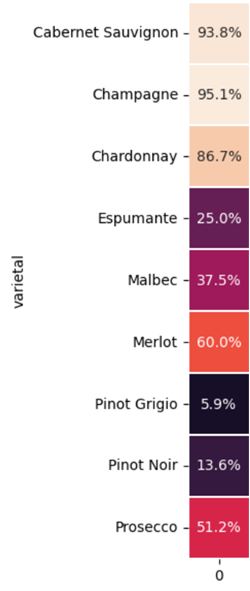

**Create a heatmap showing the % of customers by `origin` and cluster.**

⚠️ The % should be calculated down the `columns` within the cluster. ⚠️

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

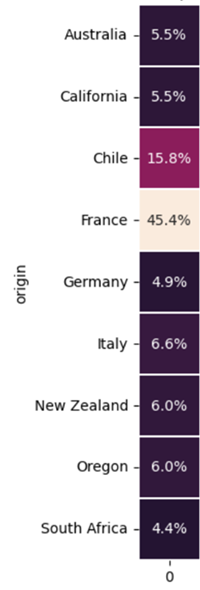

**Create a heatmap showing the % of customers by `past_peak` and cluster.**

⚠️ The % should be calculated down the `columns` within the cluster. ⚠️

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

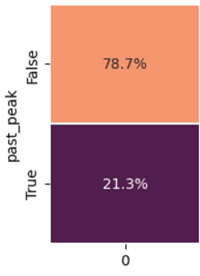

### Step 3c: Summarize the Numeric Variables and Varietal

**Create a heatmap showing the `average` and `minimum` `discount` by `varietal` and cluster.**

⚠️ In this step, we are looking for the **minimum** `discount` by wine varietal and cluster. ⚠️

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

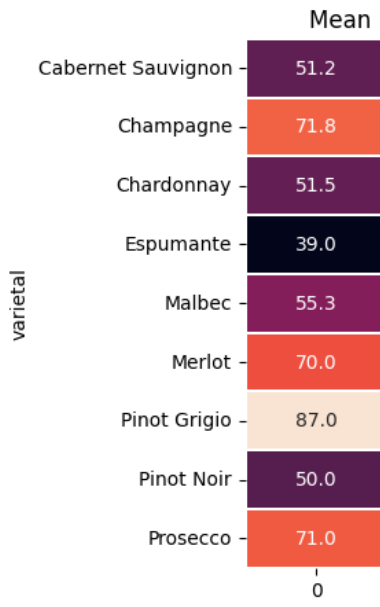

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

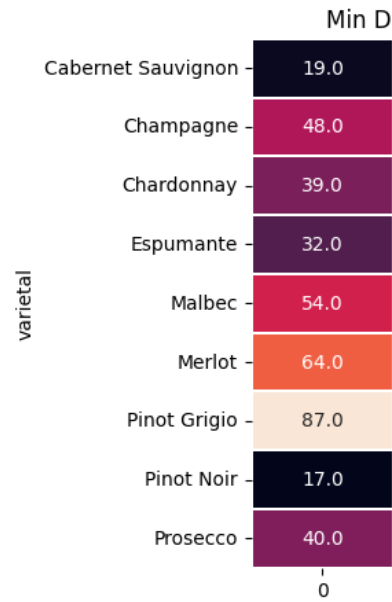

**Create a heatmap showing the `average` and `maximum` for `min_qty` by `varietal` and cluster.**

⚠️ In this step, we are looking for the **maximum** `min_qty` by wine varietal and cluster. ⚠️

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

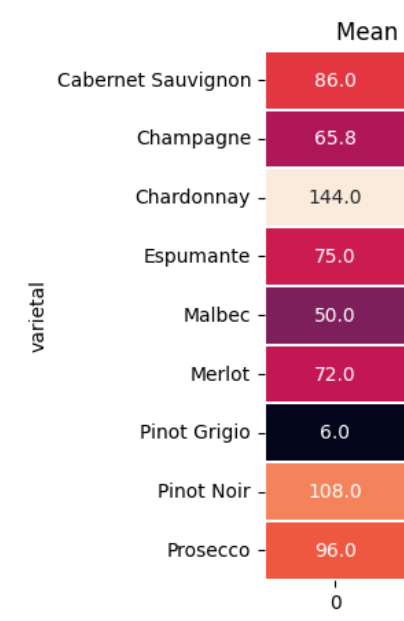

<h4 style="color:blue"> Write Your Code Below: </h4>

<h3 style="color:teal"> Sample Output: </h3>

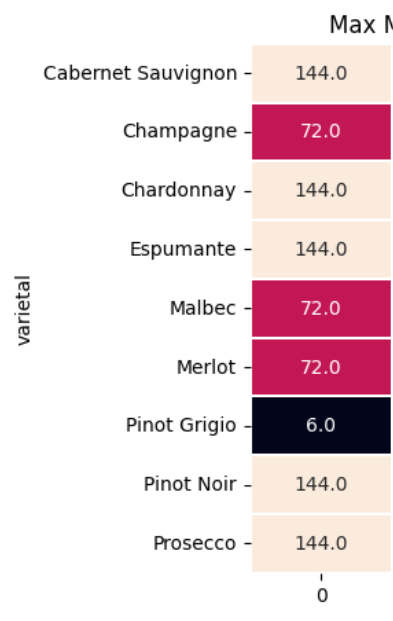

What insights did your analysis reveal about wine customers' preferences and tendencies based on the categorical and numeric variables not directly used in forming clusters?  

- How do customer clusters vary in their preference for specific wine varieties and regions of origin?  
- What patterns, if any, emerge regarding customer clusters' interest in past peak wine offerings?  
- To what extent do customer clusters exhibit a preference for minimum quantity requirements or discounts on wine offerings?

<h4 style="color:purple"> Write Your Free-Form Response Below: </h4>

## Step 4: Targeted Marketing Offer Recommendation

We have a three (3) new campaigns scheduled to run next month. The details of the offer are outlined below:

**Offer 1:**
- Varietal: `Merlot`
- Minimum Qty (kg): `72`
- Discount (%) `43`
- Origin: `Chile`
- Past Peak: `FALSE`
  
**Offer 2:**
- Varietal: `Pinot Noir`
- Minimum Qty (kg): `6`
- Discount (%) `34`
- Origin: `Italy`
- Past Peak: `FALSE`

**Offer 3:**
- Varietal: `Espumante`
- Minimum Qty (kg): `144`
- Discount (%) `50`
- Origin: `Oregon`
- Past Peak: `TRUE`

**Make a recommendation for each offer number above which customers, identified by the respective _cluster number_, the marketing newsletter/email campaign for the new campaign should be tailored for.**

<h4 style="color:purple"> Write Your Free-Form Response Below: </h4>

**Based on your analysis of past offers and varietal, do you think any of the campaigns should be modified based on past customer preferences for discount and minimum quantity within our new customer segmentation?**

<h4 style="color:purple"> Write Your Free-Form Response Below: </h4>